Deep Learning Assignment - 9 | Name - Vishal Marandi |Roll no. BTECH/10119/21 | Section - 'A'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\Asus\Downloads\LSTM.csv", index_col='Date', parse_dates=True)
df.index.freq = 'MS'

In [3]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


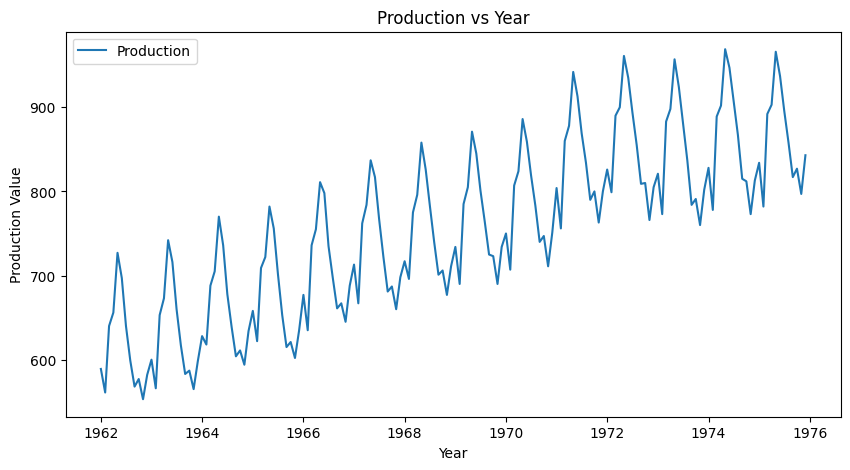

In [12]:
# Plot the production data vs. year
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Production'], label="Production")
plt.xlabel("Year")
plt.ylabel("Production Value")
plt.title("Production vs Year")
plt.legend()
plt.show()


In [5]:
train = df.iloc[:156]
test = df.iloc[156:]
print(train.size)
print(test.size)

156
12


In [7]:
# Q6: Normalize the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

In [15]:
# Q7-8: Define Timeseries Generator for both 3-month and 12-month inputs
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.metrics import mean_squared_error
# 3-month generator
n_inputs_3 = 3
n_inputs_12 = 12
generator_3 = TimeseriesGenerator(scaled_train, scaled_train, length=n_inputs_3, batch_size=1)
generator_12 = TimeseriesGenerator(scaled_train, scaled_train, length=n_inputs_12, batch_size=1)
# Sample output for 3-month generator
X_3, y_3 = generator_3[1]
print(f'Given the array (3 months): \n {X_3.flatten()}')
print(f'Predict this y: \n {y_3}')
# Sample output for 12-month generator
X, y = generator_12[1]
print(f'Given the array (12 months): \n {X.flatten()}')
print(f'Predict this y: \n {y}')

Given the array (3 months): 
 [0.01923077 0.20913462 0.24759615]
Predict this y: 
 [[0.41826923]]
Given the array (12 months): 
 [0.01923077 0.20913462 0.24759615 0.41826923 0.34615385 0.20913462
 0.11057692 0.03605769 0.05769231 0.         0.06971154 0.11298077]
Predict this y: 
 [[0.03125]]


In [16]:
# Q9-10: Define the LSTM model
model = Sequential([
    LSTM(100, activation='relu', input_shape=(n_inputs_12, 1)),  # input shape for 12-month generator
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
# Display model summary
print("Model Summary:")
model.summary()

Model Summary:


C:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Q11: Fit the model with 50 epochs
generator_12 = TimeseriesGenerator(scaled_train, scaled_train, length=n_inputs_12, batch_size=1)
history = model.fit(generator_12, epochs=50, verbose=1)

C:\Users\Asus\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0983
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0178
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0127
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0146
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0084
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0066
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0052
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0087
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0041
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0049
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0046
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0045
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0048
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0042
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 6

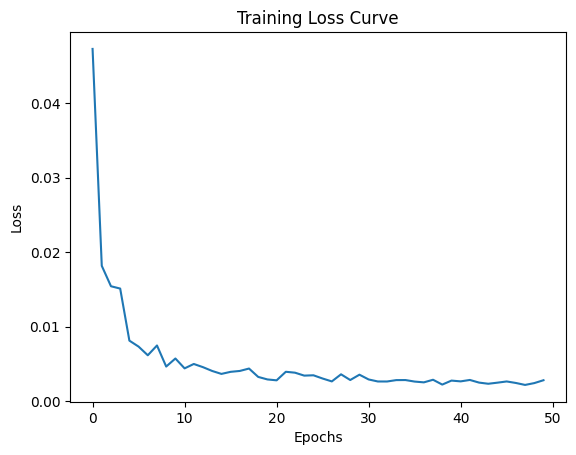

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


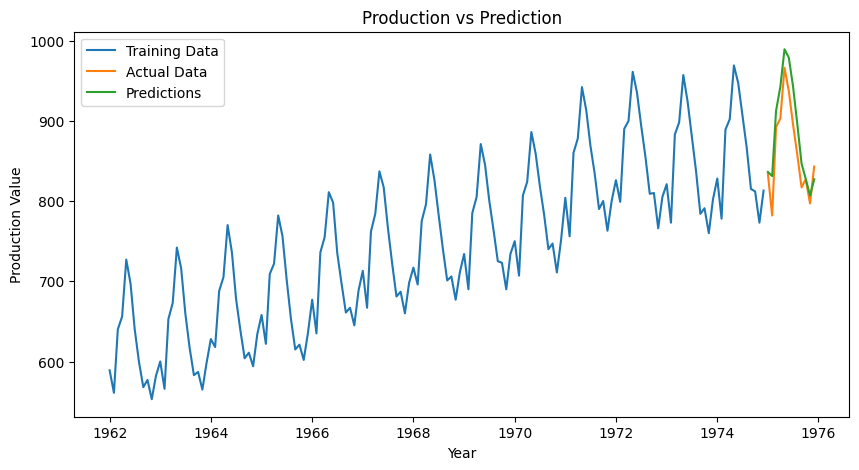

Model Error (MSE): 969.8440586116493


In [11]:

# Q12: Plot the training loss curve
plt.plot(history.history['loss'])
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Q13-14: Make predictions
predictions = []
batch = scaled_train[-n_inputs_12:]  # Last 12 months from training as initial batch
current_batch = batch.reshape((1, n_inputs_12, 1))

for i in range(len(test)):
    pred = model.predict(current_batch)[0]
    predictions.append(pred)
    current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)

# Inverse transform predictions
predictions = scaler.inverse_transform(predictions)

# Plot production vs prediction
plt.figure(figsize=(10, 5))
plt.plot(df.index[:156], train, label="Training Data")
plt.plot(df.index[156:], test, label="Actual Data")
plt.plot(df.index[156:], predictions, label="Predictions")
plt.xlabel("Year")
plt.ylabel("Production Value")
plt.title("Production vs Prediction")
plt.legend()
plt.show()

# Q15: Calculate and print Mean Squared Error (MSE)
mse = mean_squared_error(test, predictions)
print("Model Error (MSE):", mse)